# 03 — Campaign Analysis

Incrementality and impact analysis for the fictional Salomon Vestal Pro North America eCommerce launch. Notebook 02 scored the campaign against plan; this notebook asks the harder question and feeds the executive readout deck.

**Decision supported:** Did the campaign create net new value after accounting for the no-campaign baseline, cannibalization of existing franchises, halo demand, and incremental media cost — and what should change for the next launch?

## tl;dr

**The launch was incrementally successful, with cannibalization as the one watch item.** Active-flight footwear revenue ran **+35.8% above the modeled no-campaign baseline** (+$69.3K; 95% CI +32% to +40%), and total net revenue ran **+33.1%** (+$77.5K). The bottom-up decomposition — **$99.8K direct Vestal Pro revenue, less $30.5K of franchise shift, plus $8.2K of adjacent-category halo** — reconciles with the top-down estimate almost exactly, which raises confidence in both. After $43.0K of incremental media the flight netted **≈$34.5K of new revenue (1.80× on a revenue basis)**.

Against the pre-committed success criteria:

- **Incremental revenue ≥ +10%: PASS** (+35.8% footwear, +33.1% total net revenue)
- **New customers ≥ 25% of Vestal Pro buyers: PASS** (40.2%, 268 of 667)
- **Cannibalization < 25% of Vestal Pro units: WATCH** — 19–32% across three baseline specifications, and two of the three land above the line
- **Halo ≥ +5% adjacent lift: PASS** (+20.3%, 95% CI +14% to +27%) — and this time it shows up inside Vestal Pro baskets, not just site traffic

Inventory held through the 20-day flight (conversion never broke), but core sizes ran out three weeks *after* the flight ended and stayed near 42% availability, which caps the post-period tail. Returns and service load are elevated and sizing-driven. Details and caveats below.

## Context & Methods

- **Windows:** pre-campaign March 1 – May 31 (92 days), active June 1 – 20 (20 days), post June 21 – July 20 (30 days). Phases come from the `campaign_phase` column.
- **Counterfactual baseline:** linear trend + day-of-week effects, fit on the pre-period by OLS and projected through the flight. Validated on a held-out final fortnight of the pre-period before trusting it. Uncertainty on lift comes from a residual bootstrap.
- **Decomposition identity:** incremental net revenue ≈ direct Vestal Pro revenue − franchise shift + adjacent halo. Each right-hand term is measured against its own trend + day-of-week baseline, then checked against the top-down total.
- **Cannibalization:** measured in units for Sense Ride, Genesis, and Speedcross against three baseline specifications (flat pre-period mean, recent-4-week mean, trend + day-of-week), reported as a range rather than a point.
- **Channel incrementality:** no CRM holdout or geo split was fielded this flight, so channel iROAS = attributed ROAS × a uniform site-level incrementality factor (incremental ÷ attributed revenue). This is a proxy, not a measurement.
- **Media basis:** incremental media = active paid spend − the pre-period paid run-rate scaled to 20 days, since the business would have kept spending at run-rate anyway.

### Key Assumptions

Return rates in the last few weeks of data are not fully mature, so the guardrail read on returns is conservative. COGS is not tracked in this dataset — all "return on media" figures are revenue-basis, not margin-basis. The 25% cannibalization guardrail and the other criteria are the ones documented in `README.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "grid.color": "#E5E4DE", "grid.linewidth": 0.8,
    "axes.edgecolor": "#C3C2B7", "axes.labelcolor": "#52514E",
    "xtick.color": "#52514E", "ytick.color": "#52514E",
})

# Chart colors match the readout deck (Salomon red accent). Red/blue is the
# diverging pair for gain/loss; red+green fails a colorblind check.
RED = "#DA291C"
BLUE = "#2A78D6"
INK = "#0B0B0B"
GRAY = "#898781"

PRE_START = pd.Timestamp("2026-03-01")
PRE_END = pd.Timestamp("2026-05-31")
ACT_START = pd.Timestamp("2026-06-01")
ACT_END = pd.Timestamp("2026-06-20")
POST_END = pd.Timestamp("2026-07-20")
ACTIVE_DAYS = 20

EXISTING_FRANCHISES = ["Sense Ride", "Genesis", "Speedcross"]
ADJACENT = ["Trail Apparel", "Trail Accessories"]
PAID_CHANNELS = ["Email", "SMS", "Paid Social", "Paid Search", "Affiliate"]

RNG = np.random.default_rng(7)
N_BOOT = 4000

## Data

Same reproducible mock CSVs as notebook 02. `ecommerce_daily.csv` carries site topline and adjacent-category revenue, `product_daily.csv` carries franchise-level units, revenue, and availability, `channel_daily.csv` carries spend and attribution, and `customer_orders.csv` carries customer type, opt-ins, and returns.

In [2]:
ROOT = Path.cwd()
if not (ROOT / "data" / "mock").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "mock"

ecommerce = pd.read_csv(DATA_DIR / "ecommerce_daily.csv", parse_dates=["date"])
products = pd.read_csv(DATA_DIR / "product_daily.csv", parse_dates=["date"])
channels = pd.read_csv(DATA_DIR / "channel_daily.csv", parse_dates=["date"])
orders = pd.read_csv(DATA_DIR / "customer_orders.csv", parse_dates=["order_date"])
services = pd.read_csv(DATA_DIR / "consumer_services.csv", parse_dates=["contact_date"])

for name, frame, col in [
    ("ecommerce_daily", ecommerce, "date"), ("product_daily", products, "date"),
    ("channel_daily", channels, "date"), ("customer_orders", orders, "order_date"),
]:
    print(f"{name}: {len(frame):,} rows, {frame[col].min():%b %d} – {frame[col].max():%b %d}")

ecommerce_daily: 142 rows, Mar 01 – Jul 20
product_daily: 852 rows, Mar 01 – Jul 20
channel_daily: 994 rows, Mar 01 – Jul 20
customer_orders: 13,652 rows, Mar 01 – Jul 20


In [3]:
# Focused input checks before leaning on anything.
assert ecommerce["date"].is_unique
assert not products.duplicated(["date", "franchise"]).any()
assert not channels.duplicated(["date", "channel"]).any()
assert orders["order_id"].is_unique
assert set(ecommerce["campaign_phase"]) == {"Pre-campaign", "Active campaign", "Post-campaign"}
assert (ecommerce["date"].min(), ecommerce["date"].max()) == (PRE_START, POST_END)
assert products[["units_sold", "net_revenue", "core_size_availability"]].notna().all().all()
assert (channels["spend"] >= 0).all()
print("Input checks passed: unique keys, expected phases and date range, no nulls in the fields used below.")

Input checks passed: unique keys, expected phases and date range, no nulls in the fields used below.


## Results

### Incremental revenue vs the no-campaign baseline

The baseline is deliberately simple: trend + day-of-week, fit on 92 pre-period days. Before projecting it through the flight, refit on the first 78 days and score it on the held-out final fortnight.

In [4]:
def expected_baseline(frame, ycol, fit_through=PRE_END):
    """Fit trend + day-of-week on rows up to fit_through; return frame with an
    'expected' column over all rows, plus pre-period residuals."""
    frame = frame.sort_values("date").reset_index(drop=True)
    X = pd.get_dummies(frame["date"].dt.dayofweek, prefix="dow", drop_first=True).astype(float)
    X.insert(0, "t", (frame["date"] - frame["date"].min()).dt.days)
    X.insert(0, "const", 1.0)
    fit = frame["date"] <= fit_through
    beta, *_ = np.linalg.lstsq(X[fit].to_numpy(), frame.loc[fit, ycol].to_numpy(), rcond=None)
    out = frame.copy()
    out["expected"] = X.to_numpy() @ beta
    resid = out.loc[fit, ycol].to_numpy() - out.loc[fit, "expected"].to_numpy()
    return out, resid

# Backtest on the last 14 pre-period days.
pre_only = ecommerce[ecommerce["date"] <= PRE_END]
backtest, _ = expected_baseline(pre_only, "footwear_revenue", fit_through=PRE_END - pd.Timedelta(days=14))
holdout = backtest[backtest["date"] > PRE_END - pd.Timedelta(days=14)]
mape = (holdout["footwear_revenue"] - holdout["expected"]).abs().div(holdout["footwear_revenue"]).mean()
print(f"Backtest MAPE on the held-out fortnight: {mape:.1%} — acceptable for a 20-day flight read.")

Backtest MAPE on the held-out fortnight: 8.0% — acceptable for a 20-day flight read.


In [5]:
footwear, footwear_resid = expected_baseline(ecommerce, "footwear_revenue")
active_fw = footwear[footwear["campaign_phase"] == "Active campaign"]

observed = active_fw["footwear_revenue"].sum()
expected = active_fw["expected"].sum()
incremental_fw = observed - expected

boot = np.array([
    (active_fw["footwear_revenue"].to_numpy()
     - active_fw["expected"].to_numpy()
     - RNG.choice(footwear_resid, len(active_fw), replace=True)).sum()
    for _ in range(N_BOOT)
])
ci_low, ci_high = np.percentile(boot, [2.5, 97.5]) / expected

# Same read on total net revenue — this is the top-down side of the decomposition.
net, _ = expected_baseline(ecommerce, "net_revenue")
active_net = net[net["campaign_phase"] == "Active campaign"]
incremental_net = active_net["net_revenue"].sum() - active_net["expected"].sum()

print(f"Active footwear revenue: ${observed/1e3:,.1f}K observed vs ${expected/1e3:,.1f}K expected")
print(f"Incremental footwear revenue: +${incremental_fw/1e3:,.1f}K (+{incremental_fw/expected:.1%}), "
      f"95% CI {ci_low:+.1%} to {ci_high:+.1%}")
print(f"Incremental total net revenue: +${incremental_net/1e3:,.1f}K "
      f"(+{incremental_net/active_net['expected'].sum():.1%})")

Active footwear revenue: $262.8K observed vs $193.5K expected
Incremental footwear revenue: +$69.3K (+35.8%), 95% CI +32.0% to +39.7%
Incremental total net revenue: +$77.5K (+33.1%)


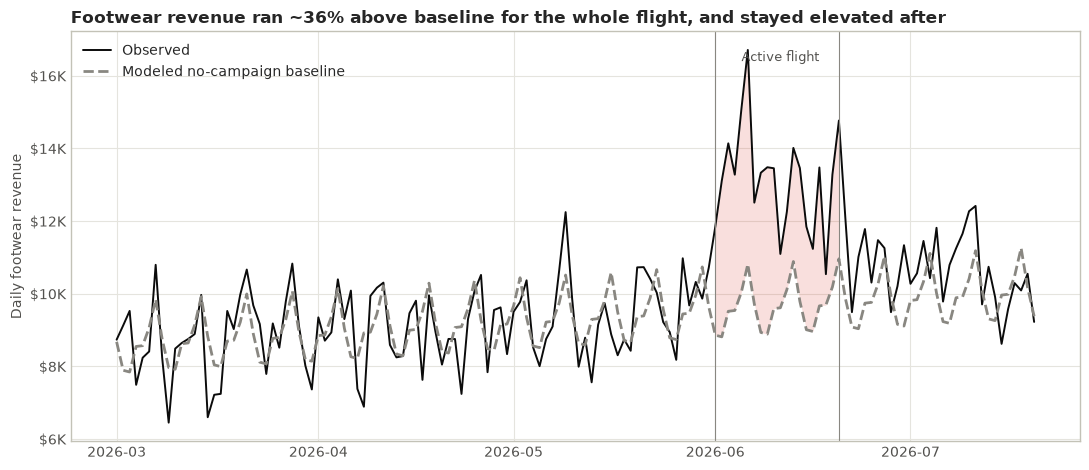

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.plot(footwear["date"], footwear["footwear_revenue"], color=INK, linewidth=1.4, label="Observed")
ax.plot(footwear["date"], footwear["expected"], color=GRAY, linewidth=2, linestyle="--",
        label="Modeled no-campaign baseline")
ax.fill_between(active_fw["date"], active_fw["expected"], active_fw["footwear_revenue"],
                where=active_fw["footwear_revenue"] >= active_fw["expected"],
                color=RED, alpha=0.15, linewidth=0)
ax.axvline(ACT_START, color=GRAY, linewidth=0.8)
ax.axvline(ACT_END, color=GRAY, linewidth=0.8)
ax.text(ACT_START + pd.Timedelta(days=10), ax.get_ylim()[1] * 0.97, "Active flight",
        ha="center", va="top", fontsize=9, color="#52514E")
ax.set_title("Footwear revenue ran ~36% above baseline for the whole flight, and stayed elevated after",
             loc="left", fontweight="bold")
ax.set_ylabel("Daily footwear revenue")
ax.yaxis.set_major_formatter(lambda v, p: f"${v/1e3:.0f}K")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

### Where the lift came from

Direct Vestal Pro revenue, less what it displaced from existing franchises, plus the adjacent-category halo. Each piece gets its own baseline, then the sum is checked against the top-down incremental above — if the two disagree badly, one of the models is wrong.

In [7]:
vestal = products[products["franchise"] == "Vestal Pro"]
vestal_active = vestal[vestal["campaign_phase"] == "Active campaign"]
vestal_direct = vestal_active["net_revenue"].sum()
vestal_units = vestal_active["units_sold"].sum()

# Franchise shift in revenue, trend + day-of-week baseline per franchise.
shift_rows = []
for franchise in EXISTING_FRANCHISES:
    frame, _ = expected_baseline(products[products["franchise"] == franchise], "net_revenue")
    active = frame[frame["campaign_phase"] == "Active campaign"]
    shift_rows.append({"Franchise": franchise,
                       "Observed": active["net_revenue"].sum(),
                       "Expected": active["expected"].sum()})
shift = pd.DataFrame(shift_rows)
shift["Delta"] = shift["Observed"] - shift["Expected"]
franchise_shift = -shift["Delta"].sum()  # positive = revenue displaced

# Halo on total adjacent-category revenue (per-category detail in the halo section).
adjacent, adjacent_resid = expected_baseline(ecommerce, "adjacent_category_revenue")
adj_active = adjacent[adjacent["campaign_phase"] == "Active campaign"]
halo_revenue = adj_active["adjacent_category_revenue"].sum() - adj_active["expected"].sum()

bottom_up = vestal_direct - franchise_shift + halo_revenue

ledger = pd.DataFrame({
    "Component": ["Vestal Pro direct revenue", "Franchise shift (cannibalization)",
                  "Adjacent-category halo", "Bottom-up incremental",
                  "Top-down incremental (site baseline)"],
    "Value": [vestal_direct, -franchise_shift, halo_revenue, bottom_up, incremental_net],
})
ledger["Value"] = ledger["Value"].map(lambda v: f"${v/1e3:+,.1f}K")
display(ledger)

assert abs(bottom_up - incremental_net) < 3_000
print(f"Decomposition reconciles: bottom-up ${bottom_up/1e3:,.1f}K vs top-down ${incremental_net/1e3:,.1f}K "
      f"(residual ${abs(bottom_up - incremental_net)/1e3:,.1f}K).")

,Component,Value
0,Vestal Pro direct revenue,$+99.8K
1,Franchise shift (cannibalization),$-30.5K
2,Adjacent-category halo,$+8.2K
3,Bottom-up incremental,$+77.5K
4,Top-down incremental (site baseline),$+77.5K


Decomposition reconciles: bottom-up $77.5K vs top-down $77.5K (residual $0.0K).


In [8]:
# Net of media: only spend above the pre-period run-rate counts against the flight.
paid = channels[channels["channel"].isin(PAID_CHANNELS)]
active_spend = paid[paid["campaign_phase"] == "Active campaign"]["spend"].sum()
pre_runrate = paid[paid["campaign_phase"] == "Pre-campaign"]["spend"].sum() / 92 * ACTIVE_DAYS
incremental_media = active_spend - pre_runrate
net_new = incremental_net - incremental_media

print(f"Active paid spend ${active_spend/1e3:,.1f}K vs ${pre_runrate/1e3:,.1f}K pre run-rate over 20 days")
print(f"Incremental media ${incremental_media/1e3:,.1f}K -> net new revenue ${net_new/1e3:,.1f}K")
print(f"Return on incremental media: {incremental_net/incremental_media:.2f}x (revenue basis; no COGS in this data)")

Active paid spend $74.6K vs $31.6K pre run-rate over 20 days
Incremental media $43.0K -> net new revenue $34.5K
Return on incremental media: 1.80x (revenue basis; no COGS in this data)


### Cannibalization

Units, not revenue, and three baseline specifications per franchise so the estimate is a range instead of a false point. Net displacement counts the Sense Ride and Genesis shortfalls less any Speedcross gain (substitution capture).

In [9]:
def unit_baselines(franchise):
    frame = products[products["franchise"] == franchise]
    pre = frame[frame["campaign_phase"] == "Pre-campaign"]
    active_units = frame[frame["campaign_phase"] == "Active campaign"]["units_sold"].sum()
    trend_frame, _ = expected_baseline(frame, "units_sold")
    return {
        "observed": active_units,
        "flat": pre["units_sold"].mean() * ACTIVE_DAYS,
        "recent": pre[pre["date"] > PRE_END - pd.Timedelta(days=28)]["units_sold"].mean() * ACTIVE_DAYS,
        "trend": trend_frame[trend_frame["campaign_phase"] == "Active campaign"]["expected"].sum(),
    }

specs = {fr: unit_baselines(fr) for fr in EXISTING_FRANCHISES}
spec_names = ["flat", "recent", "trend"]

detail = pd.DataFrame({
    "Franchise": EXISTING_FRANCHISES,
    "Active units": [specs[fr]["observed"] for fr in EXISTING_FRANCHISES],
}).set_index("Franchise")
for spec in spec_names:
    detail[f"vs {spec}"] = [f"{specs[fr]['observed'] / specs[fr][spec] - 1:+.1%}" for fr in EXISTING_FRANCHISES]
display(detail)

rates = {}
for spec in spec_names:
    displaced = sum(max(specs[fr][spec] - specs[fr]["observed"], 0) for fr in ["Sense Ride", "Genesis"])
    gained = max(specs["Speedcross"]["observed"] - specs["Speedcross"][spec], 0)
    rates[spec] = (displaced - gained) / vestal_units
    print(f"{spec:>6} spec: {displaced - gained:>4.0f} net units displaced -> {rates[spec]:.1%} of Vestal Pro units")

rate_range = (min(rates.values()), max(rates.values()))
print(f"\nCannibalization estimate: {rate_range[0]:.0%}–{rate_range[1]:.0%} of Vestal Pro units "
      f"(median spec {np.median(list(rates.values())):.0%}) against a <25% guardrail. "
      f"Two of three specs are above the line — call it a WATCH, leaning through.")

,Active units,vs flat,vs recent,vs trend
Franchise,,,,
Sense Ride,453,-13.7%,-14.5%,-17.5%
Genesis,323,-22.8%,-26.7%,-28.5%
Speedcross,444,+7.8%,+0.6%,-1.0%


  flat spec:  135 net units displaced -> 19.4% of Vestal Pro units
recent spec:  192 net units displaced -> 27.7% of Vestal Pro units
 trend spec:  225 net units displaced -> 32.4% of Vestal Pro units

Cannibalization estimate: 19%–32% of Vestal Pro units (median spec 28%) against a <25% guardrail. Two of three specs are above the line — call it a WATCH, leaning through.


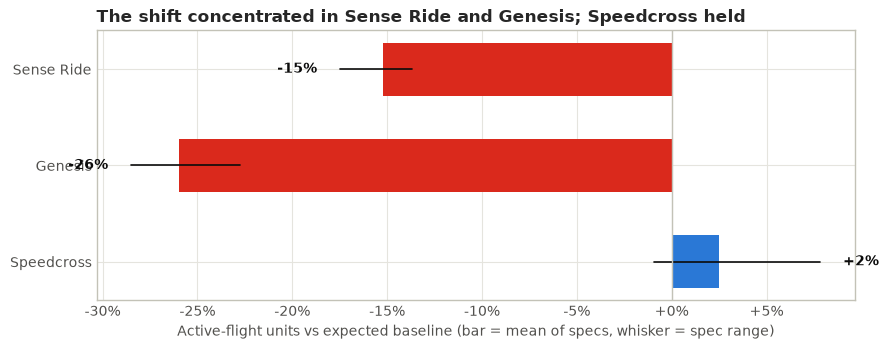

In [10]:
central = {fr: np.mean([specs[fr]["observed"] / specs[fr][s] - 1 for s in spec_names])
           for fr in EXISTING_FRANCHISES}
spans = {fr: [specs[fr]["observed"] / specs[fr][s] - 1 for s in spec_names] for fr in EXISTING_FRANCHISES}

fig, ax = plt.subplots(figsize=(9, 3.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
y = np.arange(len(EXISTING_FRANCHISES))
values = [central[fr] * 100 for fr in EXISTING_FRANCHISES]
colors = [RED if v < 0 else BLUE for v in values]
ax.barh(y, values, height=0.55, color=colors)
for i, fr in enumerate(EXISTING_FRANCHISES):
    lo, hi = min(spans[fr]) * 100, max(spans[fr]) * 100
    ax.plot([lo, hi], [i, i], color=INK, linewidth=1.2)
    offset = 1.2 if values[i] >= 0 else -1.2
    ax.text(hi + 1.2 if values[i] >= 0 else lo - 1.2, i, f"{values[i]:+.0f}%",
            va="center", ha="left" if values[i] >= 0 else "right", fontweight="bold", color=INK)
ax.axvline(0, color="#C3C2B7", linewidth=1)
ax.set_yticks(y, EXISTING_FRANCHISES)
ax.invert_yaxis()
ax.set_title("The shift concentrated in Sense Ride and Genesis; Speedcross held",
             loc="left", fontweight="bold")
ax.set_xlabel("Active-flight units vs expected baseline (bar = mean of specs, whisker = spec range)")
ax.xaxis.set_major_formatter(lambda v, p: f"{v:+.0f}%")
plt.tight_layout()
plt.show()

### Halo

Adjacent-category lift against baseline, then the more interesting question: did it arrive as bigger Vestal Pro baskets or as standalone purchases?

In [11]:
halo_rows = []
for label, frame, ycol in [
    ("Trail Apparel", products[products["franchise"] == "Trail Apparel"], "net_revenue"),
    ("Trail Accessories", products[products["franchise"] == "Trail Accessories"], "net_revenue"),
    ("All adjacent", ecommerce, "adjacent_category_revenue"),
]:
    fitted, resid = expected_baseline(frame, ycol)
    active = fitted[fitted["campaign_phase"] == "Active campaign"]
    obs, exp = active[ycol].sum(), active["expected"].sum()
    draws = np.array([
        (active[ycol].to_numpy() - active["expected"].to_numpy()
         - RNG.choice(resid, len(active), replace=True)).sum() / exp
        for _ in range(N_BOOT)
    ])
    halo_rows.append({"Category": label, "Lift": obs / exp - 1,
                      "CI low": np.percentile(draws, 2.5), "CI high": np.percentile(draws, 97.5)})
halo = pd.DataFrame(halo_rows)
halo_display = halo.copy()
for col in ["Lift", "CI low", "CI high"]:
    halo_display[col] = halo_display[col].map("{:+.1%}".format)
display(halo_display)

# Basket halo or standalone halo?
active_orders = orders[orders["campaign_phase"] == "Active campaign"]
vestal_orders = active_orders[active_orders["primary_product"] == "Vestal Pro"]
other_fw = active_orders[active_orders["primary_product"].isin(EXISTING_FRANCHISES)]
standalone_pre = orders[(orders["campaign_phase"] == "Pre-campaign")
                        & (orders["primary_product"].isin(ADJACENT))]["total_order_revenue"].sum() / 92
standalone_act = active_orders[active_orders["primary_product"].isin(ADJACENT)]["total_order_revenue"].sum() / ACTIVE_DAYS

print(f"Attach rate: {(vestal_orders['adjacent_product_revenue'] > 0).mean():.1%} of Vestal Pro orders "
      f"vs {(other_fw['adjacent_product_revenue'] > 0).mean():.1%} of other footwear orders")
print(f"Adjacent revenue attached inside Vestal Pro orders: "
      f"${vestal_orders['adjacent_product_revenue'].sum()/1e3:,.1f}K — roughly the whole modeled halo "
      f"(${halo_revenue/1e3:,.1f}K)")
print(f"Standalone adjacent demand: ${standalone_pre:,.0f}/day pre vs ${standalone_act:,.0f}/day active "
      f"({standalone_act/standalone_pre - 1:+.0%}) — flat")

,Category,Lift,CI low,CI high
0,Trail Apparel,+17.4%,+7.8%,+26.4%
1,Trail Accessories,+26.5%,+14.2%,+38.9%
2,All adjacent,+20.3%,+13.6%,+27.0%


Attach rate: 21.6% of Vestal Pro orders vs 17.5% of other footwear orders
Adjacent revenue attached inside Vestal Pro orders: $9.3K — roughly the whole modeled halo ($8.2K)
Standalone adjacent demand: $1,306/day pre vs $1,323/day active (+1%) — flat


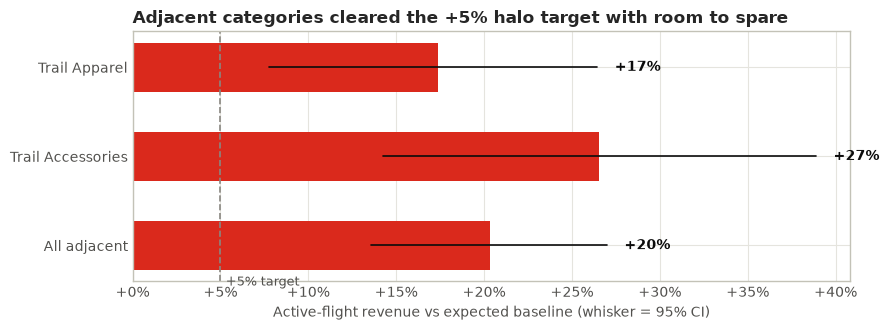

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
y = np.arange(len(halo))
ax.barh(y, halo["Lift"] * 100, height=0.55, color=RED)
for i, row in halo.iterrows():
    ax.plot([row["CI low"] * 100, row["CI high"] * 100], [i, i], color=INK, linewidth=1.2)
    ax.text(row["CI high"] * 100 + 1, i, f"{row['Lift']:+.0%}", va="center", fontweight="bold", color=INK)
ax.axvline(5, color=GRAY, linewidth=1.2, linestyle="--")
ax.text(5.3, len(halo) - 0.55, "+5% target", fontsize=9, color="#52514E")
ax.set_yticks(y, halo["Category"])
ax.invert_yaxis()
ax.set_title("Adjacent categories cleared the +5% halo target with room to spare",
             loc="left", fontweight="bold")
ax.set_xlabel("Active-flight revenue vs expected baseline (whisker = 95% CI)")
ax.xaxis.set_major_formatter(lambda v, p: f"{v:+.0f}%")
plt.tight_layout()
plt.show()

### Customer acquisition and database growth

New-to-Salomon share of Vestal Pro buyers is the headline criterion; acquisition economics and opt-in behavior decide whether those customers are worth keeping.

In [13]:
vestal_buyer_type = (vestal_orders.sort_values(["order_date", "order_id"])
                   .groupby("customer_id")["customer_type"].first())
new_ids = set(active_orders.loc[active_orders["customer_type"] == "New", "customer_id"])
first_orders = (active_orders[active_orders["customer_type"] == "New"]
                .sort_values(["order_date", "order_id"])
                .groupby("customer_id")["total_order_revenue"].first())
early_value = orders[orders["customer_id"].isin(new_ids)].groupby("customer_id")["total_order_revenue"].sum()
post_orders = orders[orders["campaign_phase"] == "Post-campaign"]
repeat_rate = post_orders[post_orders["customer_id"].isin(new_ids)]["customer_id"].nunique() / len(new_ids)
blended_cac = active_spend / len(new_ids)

pre_orders = orders[orders["campaign_phase"] == "Pre-campaign"]
adds = {
    "Email": (pre_orders["email_opt_in"].sum() / 92, active_orders["email_opt_in"].sum() / ACTIVE_DAYS),
    "SMS": (pre_orders["sms_opt_in"].sum() / 92, active_orders["sms_opt_in"].sum() / ACTIVE_DAYS),
}

acquisition = pd.DataFrame({
    "Metric": [
        "Vestal Pro active buyers", "— of which new to Salomon", "New-customer share",
        "New customers, all active orders", "Blended CAC (active paid spend / new customers)",
        "Average first order, new customers", "Early customer value (through Jul 20)",
        "Early value / CAC", "Post-window repeat rate",
    ],
    "Value": [
        f"{len(vestal_buyer_type):,}", f"{int((vestal_buyer_type == 'New').sum()):,}",
        f"{(vestal_buyer_type == 'New').mean():.1%}", f"{len(new_ids):,}",
        f"${blended_cac:,.0f}", f"${first_orders.mean():,.0f}", f"${early_value.mean():,.0f}",
        f"{early_value.mean() / blended_cac:.1f}x", f"{repeat_rate:.1%}",
    ],
})
display(acquisition)

for channel_name, (pre_rate, act_rate) in adds.items():
    print(f"{channel_name} adds/day: {pre_rate:.1f} pre -> {act_rate:.1f} active ({act_rate/pre_rate-1:+.0%})")
new_active = active_orders[active_orders["customer_type"] == "New"]
existing_active = active_orders[active_orders["customer_type"] == "Existing"]
print(f"Opt-in rates, active orders: new customers {new_active['email_opt_in'].mean():.0%} email / "
      f"{new_active['sms_opt_in'].mean():.0%} SMS vs existing {existing_active['email_opt_in'].mean():.0%} / "
      f"{existing_active['sms_opt_in'].mean():.0%}")
print(f"New customers drove ${new_active['total_order_revenue'].sum()/1e3:,.1f}K "
      f"({new_active['total_order_revenue'].sum()/active_orders['total_order_revenue'].sum():.1%} of active net revenue)")

,Metric,Value
0,Vestal Pro active buyers,667
1,— of which new to Salomon,268
2,New-customer share,40.2%
3,"New customers, all active orders",730
4,Blended CAC (active paid spend / new customers),$102
5,"Average first order, new customers",$129
6,Early customer value (through Jul 20),$188
7,Early value / CAC,1.8x
8,Post-window repeat rate,28.1%


Email adds/day: 50.3 pre -> 68.0 active (+35%)
SMS adds/day: 24.7 pre -> 33.9 active (+37%)
Opt-in rates, active orders: new customers 72% email / 40% SMS vs existing 51% / 24%
New customers drove $94.2K (30.2% of active net revenue)


### Channel efficiency

Attributed ROAS first, then scaled by the site-level incrementality factor. The scaling is uniform across channels because nothing better was instrumented this flight — CRM's true iROAS is almost certainly lower than shown (high-intent audiences), paid social's likely higher (upper-funnel assists).

In [14]:
active_channels = channels[channels["campaign_phase"] == "Active campaign"]
paid_summary = (active_channels[active_channels["channel"].isin(PAID_CHANNELS)]
                .groupby("channel")
                .agg(spend=("spend", "sum"), attributed=("attributed_revenue", "sum"),
                     new_customers=("new_customers", "sum")))
incrementality_factor = incremental_net / paid_summary["attributed"].sum()
paid_summary["roas"] = paid_summary["attributed"] / paid_summary["spend"]
paid_summary["iroas"] = paid_summary["roas"] * incrementality_factor
paid_summary["cac_new"] = paid_summary["spend"] / paid_summary["new_customers"]
paid_summary = paid_summary.sort_values("iroas", ascending=False)

paid_display = pd.DataFrame({
    "Spend": paid_summary["spend"].map("${:,.0f}".format),
    "Attributed revenue": paid_summary["attributed"].map("${:,.0f}".format),
    "ROAS": paid_summary["roas"].map("{:.1f}x".format),
    "Est. iROAS": paid_summary["iroas"].map("{:.2f}x".format),
    "New customers": paid_summary["new_customers"].astype(int),
    "CAC (new)": paid_summary["cac_new"].map("${:,.0f}".format),
})
display(paid_display)
print(f"Site incrementality factor: {incrementality_factor:.2f} "
      f"(${incremental_net/1e3:,.1f}K incremental / ${paid_summary['attributed'].sum()/1e3:,.1f}K attributed)")

social = paid_summary.loc["Paid Social"]
print(f"Paid Social: {social['new_customers']:.0f} of {len(new_ids)} new customers "
      f"({social['new_customers']/len(new_ids):.0%}) at ${social['cac_new']:,.0f} CAC vs "
      f"${early_value.mean():,.0f} early value — pays back as acquisition, thinly, not as revenue.")

organic_direct = active_channels[active_channels["channel"].isin(["Organic", "Direct"])]
od_pre = channels[(channels["campaign_phase"] == "Pre-campaign")
                  & (channels["channel"].isin(["Organic", "Direct"]))]
print(f"Unpaid spillover: Organic + Direct attributed revenue/day "
      f"${od_pre['attributed_revenue'].sum()/92:,.0f} pre -> "
      f"${organic_direct['attributed_revenue'].sum()/ACTIVE_DAYS:,.0f} active "
      f"({(organic_direct['attributed_revenue'].sum()/ACTIVE_DAYS)/(od_pre['attributed_revenue'].sum()/92)-1:+.0%})")

,Spend,Attributed revenue,ROAS,Est. iROAS,New customers,CAC (new)
channel,,,,,,
Email,"$3,255","$83,945",25.8x,8.65x,39,$83
SMS,"$2,490","$24,017",9.6x,3.24x,20,$124
Affiliate,"$4,991","$20,771",4.2x,1.40x,61,$82
Paid Search,"$18,849","$58,008",3.1x,1.03x,175,$108
Paid Social,"$44,969","$44,247",1.0x,0.33x,297,$151


Site incrementality factor: 0.34 ($77.5K incremental / $231.0K attributed)
Paid Social: 297 of 730 new customers (41%) at $151 CAC vs $188 early value — pays back as acquisition, thinly, not as revenue.
Unpaid spillover: Organic + Direct attributed revenue/day $4,083 pre -> $5,701 active (+40%)


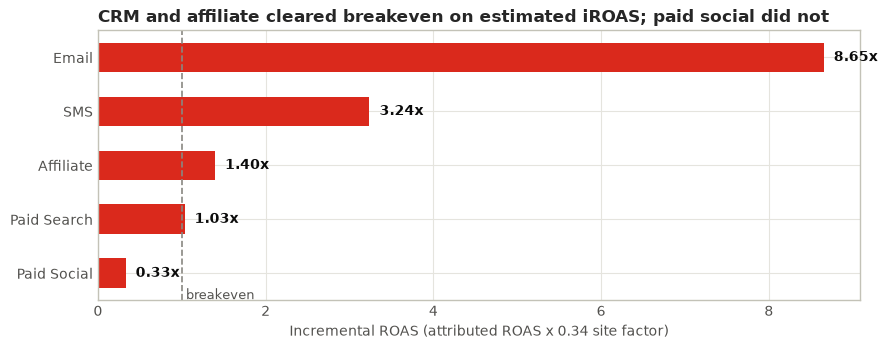

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
y = np.arange(len(paid_summary))
ax.barh(y, paid_summary["iroas"], height=0.55, color=RED)
for i, (name, row) in enumerate(paid_summary.iterrows()):
    ax.text(row["iroas"] + 0.12, i, f"{row['iroas']:.2f}x", va="center", fontweight="bold", color=INK)
ax.axvline(1, color=GRAY, linewidth=1.2, linestyle="--")
ax.text(1.05, len(paid_summary) - 0.52, "breakeven", fontsize=9, color="#52514E")
ax.set_yticks(y, paid_summary.index)
ax.invert_yaxis()
ax.set_title("CRM and affiliate cleared breakeven on estimated iROAS; paid social did not",
             loc="left", fontweight="bold")
ax.set_xlabel(f"Incremental ROAS (attributed ROAS x {incrementality_factor:.2f} site factor)")
plt.tight_layout()
plt.show()

### Inventory and guardrails

The question that decided the last readout — did availability constrain the flight? — has a different answer on this data.

In [16]:
vestal_flight = vestal[vestal["date"] >= ACT_START].copy()
vestal_flight["week"] = (vestal_flight["date"] - ACT_START).dt.days // 7 + 1
active_weeks = vestal_flight[vestal_flight["campaign_phase"] == "Active campaign"]
weekly = active_weeks.groupby("week").agg(
    availability=("core_size_availability", "mean"),
    sessions=("sessions", "sum"), units=("units_sold", "sum"))
weekly["sell_through"] = weekly["units"] / weekly["sessions"]
weekly_display = weekly.copy()
weekly_display["availability"] = weekly_display["availability"].map("{:.1%}".format)
weekly_display["sell_through"] = weekly_display["sell_through"].map("{:.2%}".format)
display(weekly_display)

week1_conv = weekly.loc[1, "sell_through"]
later = weekly.loc[2:]
unmet_units = week1_conv * later["sessions"].sum() - later["units"].sum()
asp = vestal_direct / vestal_units
print(f"Unmet demand if weeks 2–3 had converted at week-1 rate: {unmet_units:.0f} units "
      f"(~${unmet_units*asp/1e3:,.1f}K) — not material. Conversion held through the flight.")

post_availability = vestal[vestal["campaign_phase"] == "Post-campaign"]["core_size_availability"].mean()
post_revenue = vestal[vestal["campaign_phase"] == "Post-campaign"]["net_revenue"].sum()
print(f"But core-size availability averaged {post_availability:.0%} across the post period "
      f"(vs {weekly['availability'].iloc[-1]:.0%} in week 3) — the stockout happened after the flight, "
      f"and it caps the ${post_revenue/1e3:,.1f}K post-period tail.")

,availability,sessions,units,sell_through
week,,,,
1,98.0%,5795,268,4.62%
2,91.9%,5139,246,4.79%
3,73.7%,4174,180,4.31%


Unmet demand if weeks 2–3 had converted at week-1 rate: 5 units (~$0.7K) — not material. Conversion held through the flight.
But core-size availability averaged 44% across the post period (vs 74% in week 3) — the stockout happened after the flight, and it caps the $56.5K post-period tail.


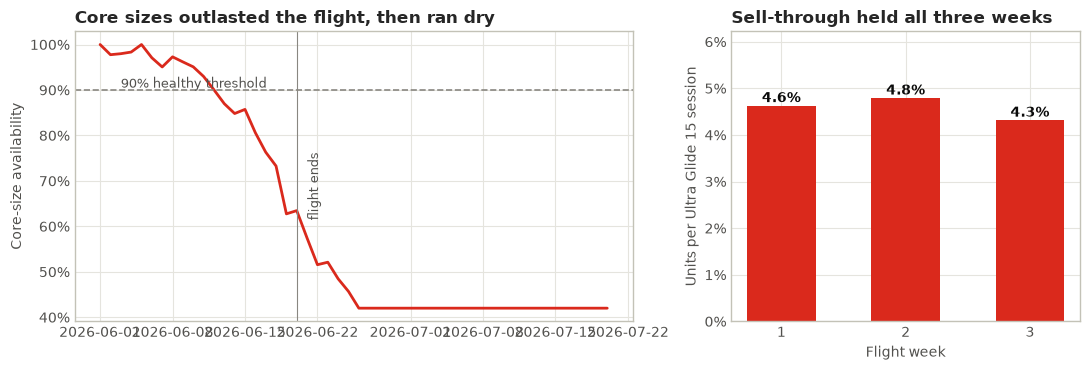

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), width_ratios=[1.6, 1])
fig.patch.set_facecolor("white")
for ax in (ax1, ax2):
    ax.set_facecolor("white")

availability_window = vestal[vestal["date"] >= ACT_START]
ax1.plot(availability_window["date"], availability_window["core_size_availability"],
         color=RED, linewidth=2)
ax1.axhline(0.9, color=GRAY, linewidth=1.2, linestyle="--")
ax1.text(availability_window["date"].iloc[2], 0.905, "90% healthy threshold", fontsize=9, color="#52514E")
ax1.axvline(ACT_END, color=GRAY, linewidth=0.8)
ax1.text(ACT_END + pd.Timedelta(days=1), 0.62, "flight ends", fontsize=9, color="#52514E", rotation=90)
ax1.set_title("Core sizes outlasted the flight, then ran dry", loc="left", fontweight="bold")
ax1.set_ylabel("Core-size availability")
ax1.yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")

ax2.bar(weekly.index.astype(str), weekly["sell_through"] * 100, width=0.55, color=RED)
for i, v in enumerate(weekly["sell_through"] * 100):
    ax2.text(i, v + 0.08, f"{v:.1f}%", ha="center", fontweight="bold", color=INK)
ax2.set_title("Sell-through held all three weeks", loc="left", fontweight="bold")
ax2.set_xlabel("Flight week")
ax2.set_ylabel("Units per Vestal Pro session")
ax2.set_ylim(0, weekly["sell_through"].max() * 130)
ax2.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
plt.tight_layout()
plt.show()

In [18]:
pre_ec = ecommerce[ecommerce["campaign_phase"] == "Pre-campaign"]
act_ec = ecommerce[ecommerce["campaign_phase"] == "Active campaign"]
post_ec = ecommerce[ecommerce["campaign_phase"] == "Post-campaign"]
vestal_post_orders = orders[(orders["campaign_phase"] == "Post-campaign")
                          & (orders["primary_product"] == "Vestal Pro")]
contacts_per_order = (services.groupby("campaign_phase").size()
                      / orders.groupby("campaign_phase").size())
reason_mix = pd.DataFrame({
    "pre_per_day": services[services["campaign_phase"] == "Pre-campaign"].groupby("contact_reason").size() / 92,
    "active_per_day": services[services["campaign_phase"] == "Active campaign"].groupby("contact_reason").size() / ACTIVE_DAYS,
}).fillna(0)
reason_mix["ratio"] = reason_mix["active_per_day"] / reason_mix["pre_per_day"].replace(0, np.nan)

guardrails = pd.DataFrame({
    "Guardrail": ["Average order value", "Site conversion rate", "Site return rate",
                  "Vestal Pro return rate (orders)", "Other-footwear return rate (orders)",
                  "Service contacts per order"],
    "Pre": [f"${pre_ec['net_revenue'].sum()/pre_ec['orders'].sum():,.0f}",
            f"{pre_ec['orders'].sum()/pre_ec['sessions'].sum():.2%}",
            f"{pre_ec['return_rate'].mean():.1%}", "—",
            f"{orders[(orders['campaign_phase']=='Pre-campaign') & (orders['primary_product'].isin(EXISTING_FRANCHISES))]['returned'].mean():.1%}",
            f"{contacts_per_order['Pre-campaign']:.1%}"],
    "Active": [f"${act_ec['net_revenue'].sum()/act_ec['orders'].sum():,.0f}",
               f"{act_ec['orders'].sum()/act_ec['sessions'].sum():.2%}",
               f"{act_ec['return_rate'].mean():.1%}",
               f"{vestal_orders['returned'].mean():.1%}",
               f"{other_fw['returned'].mean():.1%}",
               f"{contacts_per_order['Active campaign']:.1%}"],
    "Post": ["—",
             f"{post_ec['orders'].sum()/post_ec['sessions'].sum():.2%}",
             f"{post_ec['return_rate'].mean():.1%}",
             f"{vestal_post_orders['returned'].mean():.1%}", "—",
             f"{contacts_per_order['Post-campaign']:.1%}"],
})
display(guardrails)

top_risers = reason_mix.sort_values("ratio", ascending=False).head(3)
print("Fastest-rising contact reasons (active vs pre, per day):")
for reason, row in top_risers.iterrows():
    print(f"  {reason}: {row['pre_per_day']:.1f}/day -> {row['active_per_day']:.1f}/day ({row['ratio']:.1f}x)")
print("Product-defect contacts stayed near zero — the return story is sizing, not quality.")

,Guardrail,Pre,Active,Post
0,Average order value,$124,$133,—
1,Site conversion rate,2.33%,2.47%,2.31%
2,Site return rate,7.0%,8.4%,8.0%
3,Vestal Pro return rate (orders),—,15.0%,14.1%
4,Other-footwear return rate (orders),8.6%,8.5%,—
5,Service contacts per order,4.4%,7.0%,6.7%


Fastest-rising contact reasons (active vs pre, per day):
  Product comparison: 0.5/day -> 2.4/day (4.6x)
  Inventory availability: 0.4/day -> 1.3/day (3.3x)
  Sizing and fit: 0.9/day -> 2.0/day (2.3x)
Product-defect contacts stayed near zero — the return story is sizing, not quality.


## Takeaways

1. **The launch cleared its primary bar with room to spare:** footwear revenue ran **+35.8% above the no-campaign baseline** (+$69.3K; 95% CI +32% to +40%) and total net revenue **+33.1%** (+$77.5K). After $43.0K of incremental media, ≈**$34.5K of net new revenue** — 1.80× on a revenue basis. A margin-basis view needs COGS, which this dataset does not track.
2. **The decomposition closes**, which is the strongest internal-consistency check available without a holdout: $99.8K Vestal Pro direct − $30.5K franchise shift + $8.2K halo lands within rounding of the top-down $77.5K.
3. **Acquisition beat its criterion decisively:** 40.2% of Vestal Pro buyers were new (target ≥25%), blended CAC of $102 vs $188 early customer value (1.8×), a 28.1% post-window repeat rate, and database adds up 35% (email) and 37% (SMS) per day.
4. **Cannibalization is the watch item and probably through the guardrail:** 19–32% of Vestal Pro units across specifications, median ≈28% vs the <25% line, concentrated in Sense Ride and Genesis. The launch is still clearly net-positive, but the next readout should say "at or above the guardrail," not "under it."
5. **The halo is real and basket-borne this time:** +20.3% adjacent lift (CI +14% to +27%), attach at 21.6% on Vestal Pro orders vs 17.5% on other footwear, and the attached adjacent revenue inside Vestal Pro orders (~$9.3K) accounts for essentially the whole modeled halo while standalone adjacent demand stayed flat. Bundles and cross-sell are working — the play is to scale them.
6. **Channel economics repeat the familiar shape:** email 8.7× / SMS 3.2× / affiliate 1.4× estimated iROAS, paid search at breakeven, paid social at 0.33× — but social sourced 41% of new customers at $151 CAC against $188 early value, which is payback as acquisition, thinly. Judge it on a CAC target and a day-90 LTV read next flight, and remember every iROAS here leans on one uniform 0.34 incrementality factor.
7. **Inventory held during the flight but failed after it:** availability bottomed at 74% in week 3 with sell-through intact (unmet demand ≈$1K), then fell to ~44% for the entire post period, capping a $56.5K tail that was still running +17% above the pre-period run-rate. Buy depth for the flight was right; replenishment for the tail was not.
8. **Instrument before the next launch:** a CRM holdout and a geo split (to replace the uniform incrementality factor), COGS and unsubscribe capture, and a pre-committed CAC target. Returns (site 8.4% active, Vestal Pro ~15% and sizing-driven) are within launch expectations but not fully mature — worth a re-read once the post-period returns settle.